In [8]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [9]:
Imagesize=256
Batchsize=64
Channels=3
Epochs=40 #trail



In [10]:
#You can download datasets into batches

In [11]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
"plantvillage",
 shuffle=True,
 image_size=(Imagesize,Imagesize),
 batch_size=Batchsize
)

Found 3854 files belonging to 4 classes.


In [12]:
class_names=dataset.class_names
class_names

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___healthy']

In [13]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())
#every element is tensor thus we need to convert it into numpy
#64 size of batch and size of image is 256
#3=rgb channels

(64, 256, 256, 3)
[1 1 2 2 3 2 3 0 2 2 0 2 1 1 1 1 3 2 2 1 2 2 2 1 1 2 1 3 3 1 0 1 1 3 2 1 2
 2 2 3 1 3 3 2 2 3 3 3 3 3 1 3 2 3 0 2 0 1 0 3 0 3 3 3]


In [14]:
#to access 1 batch
for image_batch,label_batch in dataset.take(1):
    print(image_batch[0])

tf.Tensor(
[[[171. 169. 172.]
  [167. 165. 168.]
  [163. 161. 164.]
  ...
  [110. 109. 107.]
  [122. 121. 119.]
  [102. 101.  99.]]

 [[173. 171. 174.]
  [169. 167. 170.]
  [167. 165. 168.]
  ...
  [104. 103. 101.]
  [111. 110. 108.]
  [117. 116. 114.]]

 [[175. 173. 176.]
  [173. 171. 174.]
  [171. 169. 172.]
  ...
  [104. 103. 101.]
  [105. 104. 102.]
  [124. 123. 121.]]

 ...

 [[191. 195. 198.]
  [191. 195. 198.]
  [191. 195. 198.]
  ...
  [158. 157. 162.]
  [153. 152. 157.]
  [150. 149. 154.]]

 [[194. 198. 201.]
  [193. 197. 200.]
  [191. 195. 198.]
  ...
  [155. 154. 159.]
  [149. 148. 153.]
  [147. 146. 151.]]

 [[196. 200. 203.]
  [194. 198. 201.]
  [192. 196. 199.]
  ...
  [153. 152. 157.]
  [150. 149. 154.]
  [150. 149. 154.]]], shape=(256, 256, 3), dtype=float32)


In [15]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch[0].numpy())

[[[187. 170. 163.]
  [170. 153. 146.]
  [181. 164. 157.]
  ...
  [131. 114. 107.]
  [150. 133. 126.]
  [124. 107. 100.]]

 [[177. 160. 153.]
  [170. 153. 146.]
  [189. 172. 165.]
  ...
  [167. 150. 143.]
  [135. 118. 111.]
  [140. 123. 116.]]

 [[171. 154. 147.]
  [173. 156. 149.]
  [194. 177. 170.]
  ...
  [169. 150. 143.]
  [138. 119. 112.]
  [133. 114. 107.]]

 ...

 [[174. 161. 153.]
  [177. 164. 156.]
  [183. 170. 162.]
  ...
  [155. 138. 130.]
  [154. 137. 129.]
  [151. 134. 126.]]

 [[171. 158. 150.]
  [179. 166. 158.]
  [181. 168. 160.]
  ...
  [155. 138. 130.]
  [153. 136. 128.]
  [147. 130. 122.]]

 [[185. 172. 164.]
  [178. 165. 157.]
  [154. 141. 133.]
  ...
  [150. 133. 125.]
  [146. 129. 121.]
  [139. 122. 114.]]]


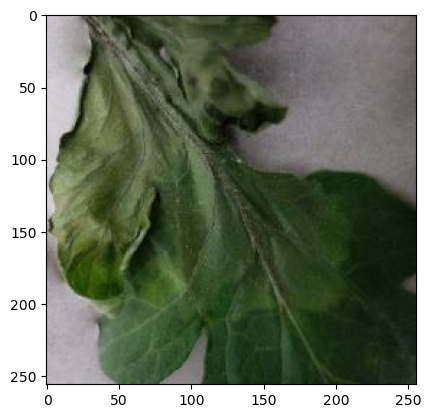

In [16]:
for image_batch,label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))#converting into int
#uint=unsigned integer not store -ve value
#8 bit=0-255
#used coz image will range in 0-255 only rgb range
    

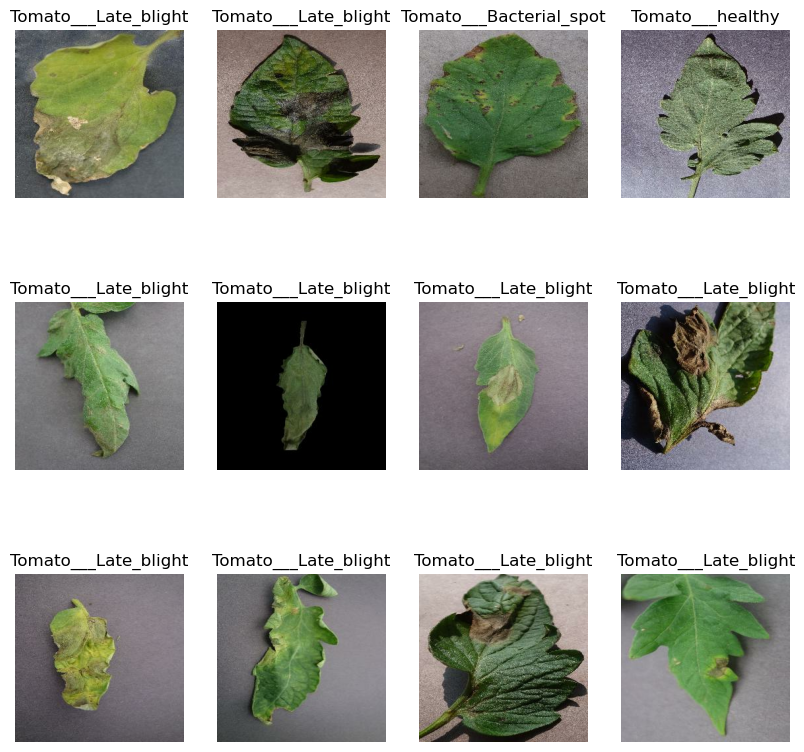

In [17]:
plt.figure(figsize=(10,10))#size of image
for image_batch, label_batch in dataset.take(1):  
    for i in range(12):  
        plt.subplot(3, 4, i+1)#3*4 grid

        # Display the i-th image from the batch
        plt.imshow(image_batch[i].numpy().astype("uint8"))  

        # Get the corresponding class label
        plt.title(class_names[label_batch[i].numpy()])  
        plt.axis("off")  

plt.show()


In [18]:
#80%==training
#20%==10% validation,10% test
#we run 40 epoch at end of evry one epoch we run these
#10% validation and when done with 40 epch then work on 10%test


In [19]:
train_size=0.8
len(dataset)*train_size
#count of batches


48.800000000000004

In [20]:
import tensorflow as tf

try:
    batch_size = 64
    dummy_input = tf.random.normal([batch_size, 224, 224, 3])  # Simulating 96 RGB images
    print("Batch size 64 is working fine!")
except:
    print("Batch size 64 is too large, try reducing it.")

    

Batch size 64 is working fine!


# Spliting ds into validation test and train

In [21]:
train_ds=dataset.take(64)
len(train_ds)

61

In [22]:
test_ds=dataset.skip(64)#temporary test dataset
len(test_ds)

0

In [23]:
val_size=0.1
len(dataset)*val_size
#require 12 samples from test datset

6.1000000000000005

In [24]:
# if ds is less than 10000 then use shuffle size 5000 

In [25]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=5000):
    ds_size=len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    
    train_ds=ds.take(train_size)
    
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    
    return train_ds,val_ds,test_ds

In [26]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)

In [27]:
len(train_ds)

48

In [28]:
len(val_ds)

6

In [29]:
len(test_ds)

7

In [30]:
#cache()#read iamge from disk for next iternation it will keep
#that iamge in memory
#prefetch()
#if cpu is busy it will load another batch from the disk

In [31]:

train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# Prepocessing

In [32]:
#scale 0-255 rgb scale divide by 255 so you no.get b/w 0 and1 
#resize go to our model during prediction if it is of other dimesnion 
#so resize will convert into that dimension which we have given

In [33]:
from tensorflow import keras
from keras import layers


In [34]:
#The error AttributeError: module 'keras._tf_keras.keras.layers'
#has no attribute 'experimental' happens because the experimental 
#module was removed in TensorFlow 2.9+.


#Instead of using layers.experimental.preprocessing.Resizing,
#update your code to use keras.layers directly:




In [35]:
import tensorflow as tf
from tensorflow import keras
from keras import layers



resize_and_rescale = keras.Sequential([
    layers.Resizing(Imagesize, Imagesize),  # Remove "experimental"
    layers.Rescaling(1.0 / 255)
])


In [36]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    
])

In [37]:
#Build the model and train

# Building the model using cnn

In [38]:
#Convolutional and pooling layer
#dense layer
#filter:- to detect diff parts of image e.g in image reconigation
#1st filter:-nose,eyes,ears(3 layers)
#2nd filter:-hands and legs for body(2 layers)
#pooling:-suppose you have 4*4 data so in 4*4 you taking 
#max number among 4
#flatten:-so that it is array of neurons
#softmax=normalize the probability of classes

In [39]:
import numpy as np

image = np.random.rand(224, 224, 3)  # Example image
image = np.expand_dims(image, axis=0)  # Now shape is (1, 224, 224, 3)


In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models

Imagesize = 224  # Example size
Channels = 3    # Example channels
n_classes = 4

# Example resize_and_rescale and data_augmentation layers. Replace with your actual implementation
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(Imagesize, Imagesize),
    layers.Rescaling(1./255)
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(Imagesize, Imagesize, Channels)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),  # Flatten the feature maps
    layers.Dense(128, activation='relu'),  # Add a dense layer
    layers.Dense(n_classes, activation='softmax')  # Output layer with softmax
])
test_input = tf.random.normal(shape=(1, Imagesize, Imagesize, Channels))
_ = model(test_input)#building a dumy model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])






C:\Users\Mishika\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (1, 224, 224, 3)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_3 (Sequential)            │ (1, 224, 224, 3)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (1, 222, 222, 32)           │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (1, 111, 111, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (1, 109, 109, 64)           │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (1, 54, 54, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (1, 52, 52, 64)             │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (1, 26, 26, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (1, 24, 24, 64)             │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (1, 12, 12, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (1, 10, 10, 64)             │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (1, 5, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (1, 3, 3, 64)               │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (1, 1, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (1, 64)                     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (1, 128)                    │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 4)                      │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 175,940 (687.27 KB)

 Trainable params: 175,940 (687.27 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0


In [36]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_augmented_model.keras', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_ds,
    epochs=Epochs,
    batch_size=Batchsize,
    verbose=1,
    validation_data=val_ds,
    callbacks=callbacks
)
    


Epoch 1/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.4104 - loss: 1.2492 - val_accuracy: 0.5807 - val_loss: 1.0742
Epoch 2/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.5949 - loss: 0.9950 - val_accuracy: 0.5938 - val_loss: 1.0165
Epoch 3/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6573 - loss: 0.8092 - val_accuracy: 0.7266 - val_loss: 0.6916
Epoch 4/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7399 - loss: 0.6043 - val_accuracy: 0.6016 - val_loss: 1.1977
Epoch 5/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7686 - loss: 0.5847 - val_accuracy: 0.7578 - val_loss: 0.6168
Epoch 6/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.8033 - loss: 0.4766 - val_accuracy: 0.8151 - val_loss: 0.4451
Epoch 7/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8047 - loss: 0.4517 - val_accuracy: 0.8203 - val_loss: 0.5487
Epoch 8/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8503 - loss: 0.3787 - val_accuracy: 0.7865 - val_l

In [42]:
model.save("model.keras")


NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("model.keras")
#in new notebook

In [38]:
import os

print(os.path.exists("model.keras"))  # Will print True if it’s saved


True


In [2]:
from tensorflow.keras.models import load_model

try:
    loaded_model = load_model("model.keras")
    print("Model loaded successfully!")
except Exception as e:
    print("Error loading model:", e)


Model loaded successfully!


In [3]:
loaded_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (1, 224, 224, 3)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_3 (Sequential)            │ (1, 224, 224, 3)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (1, 222, 222, 32)           │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (1, 111, 111, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (1, 109, 109, 64)           │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (1, 54, 54, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (1, 52, 52, 64)             │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (1, 26, 26, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (1, 24, 24, 64)             │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (1, 12, 12, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (1, 10, 10, 64)             │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (1, 5, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (1, 3, 3, 64)               │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (1, 1, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (1, 64)                     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (1, 128)                    │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 4)                      │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 527,822 (2.01 MB)

 Trainable params: 175,940 (687.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 351,882 (1.34 MB)

In [40]:
scores=model.evaluate(test_ds)

NameError: name 'model' is not defined

In [41]:
scores

NameError: name 'scores' is not defined

In [ ]:
history

In [ ]:
#Agar aap kernel restart karna chahte ho ya future me model use karna chahte ho, 
#to dobara train karne ki zaroorat nahi hai. Bas saved model load kar lo.


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("model.keras")


In [ ]:
predictions = model.predict(test_ds)
print(predictions)


In [ ]:
history.params

In [5]:
history.history.keys()

NameError: name 'history' is not defined

In [6]:
len(history.history["accuracy"])

NameError: name 'history' is not defined

In [51]:
acc=history.history["accuracy"]
val_acc=history.history["val_accuracy"]

loss=history.history["loss"]
val_loss=history.history["val_loss"]

In [52]:
#Training vs test accuracy

Text(0.5, 1.0, 'Training and Validation Accuracy')

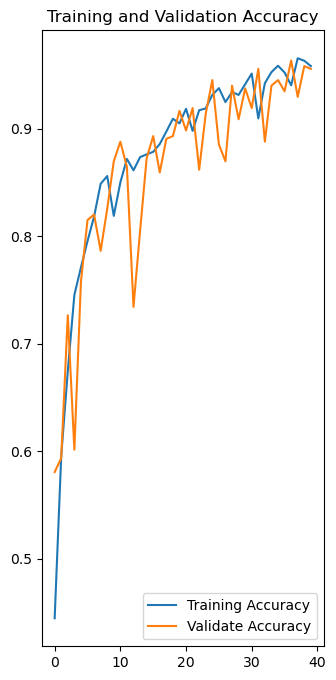

In [53]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(Epochs),acc , label="Training Accuracy")
plt.plot(range(Epochs), val_acc,label='Validate Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")
#since the accuracy is increasing we can see that from 0.4 to 1.0


# Loss Chart

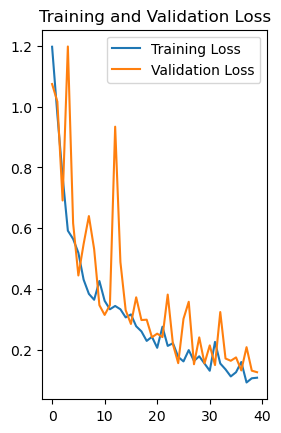

In [54]:
plt.subplot(1,2,2)
plt.plot(range(Epochs),loss,label="Training Loss")
plt.plot(range(Epochs),val_loss,label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()
#since the loss is decreasing these is good sign for it

# Prediction

In [7]:
#due to shuffling it will changing
for images_batch,label_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype('uint8')
    first_label=label_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("first image's actual label:",class_names[first_label])#actual o/p
    
    batch_prediction=model.predict(images_batch)
    print("predictes label",class_names[np.argmax(batch_prediction[0])])

NameError: name 'test_ds' is not defined

In [56]:
#[9.9892929e-02 8.8683534e-01 1.3269523e-02 2.1786009e-06]
#these is because we have three neurons and also due to softmax

In [57]:
#converting into array
#creating batch
#call predict function
#figure out predict class
#find out confidence

In [58]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)#create batch
    predictions=model.predict(img_array)
    
   
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)
    return predicted_class , confidence

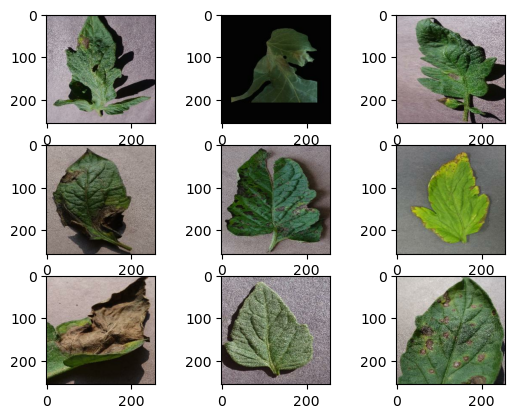

In [59]:
for images, labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        

In [60]:
#for 9 images

In [61]:
#don't want axis
"""plt.figure(figsize=(15,15))#inc the size of images
for images, labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        
        plt.title(f"Actual: {actual_class} \n Predicted {predicted_class}\n Confidence: {confidence}%")
        plt.axis("off")"""

'plt.figure(figsize=(15,15))#inc the size of images\nfor images, labels in test_ds.take(1):\n    for i in range(9):\n        ax=plt.subplot(3,3,i+1)\n        plt.imshow(images[i].numpy().astype("uint8"))\n        \n        predicted_class,confidence=predict(model,images[i].numpy())\n        actual_class=class_names[labels[i]]\n        \n        plt.title(f"Actual: {actual_class} \n Predicted {predicted_class}\n Confidence: {confidence}%")\n        plt.axis("off")'

# for 1 Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


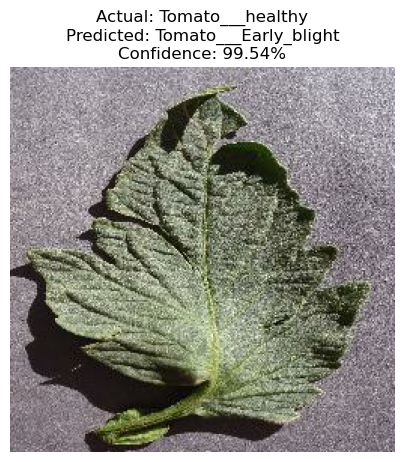

In [63]:
import matplotlib.pyplot as plt

# Take a single image from the dataset
for images, labels in test_ds.take(1):  
    image = images[0].numpy()  # Extract the first image as a NumPy array
    actual_class = class_names[labels[0]]  # Get the actual class label

# Make prediction (ensure image has correct batch shape)
predicted_class, confidence = predict(model, image)

# Display the image
plt.figure(figsize=(5, 5))  # Adjust figure size as needed
plt.imshow(image.astype("uint8"))
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
plt.axis("off")  # Remove axes
plt.show()


In [64]:
np.save("predictions.npy", predictions)


In [65]:
loaded_preds = np.load("predictions.npy")


In [66]:
model.save("..model1.keras")  
#saving 2nd time as if you want to make any changes 
#you do in these model1

In [67]:
import os
os.listdir("../models")#list of directories


['model.keras', 'model1.keras']

In [69]:
loss, accuracy = model.evaluate(val_ds)  
print(f" Accuracy: {accuracy*100:.2f}%")
print(f" Error Rate: {(1 - accuracy)*100:.2f}%")


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 449ms/step - accuracy: 0.9528 - loss: 0.1354
 Accuracy: 95.57%
 Error Rate: 4.43%


In [43]:
from tensorflow.keras.models import load_model

try:
    loaded_model = load_model("model.keras")
    print("Model loaded successfully!")
except Exception as e:
    print("Error loading model:", e)

Model loaded successfully!


In [45]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)#create batch
    predictions=model.predict(img_array)
    
   
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)
    return predicted_class , confidence

In [46]:
import matplotlib.pyplot as plt

# Take a single image from the dataset
for images, labels in test_ds.take(1):  
    image = images[0].numpy()  # Extract the first image as a NumPy array
    actual_class = class_names[labels[0]]  # Get the actual class label

# Make prediction (ensure image has correct batch shape)
predicted_class, confidence = predict(model, image)

# Display the image
plt.figure(figsize=(5, 5))  # Adjust figure size as needed
plt.imshow(image.astype("uint8"))
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
plt.axis("off")  # Remove axes
plt.show()


NameError: name 'model' is not defined

# FAST API SERVER